# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [ ]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [ ]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [ ]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

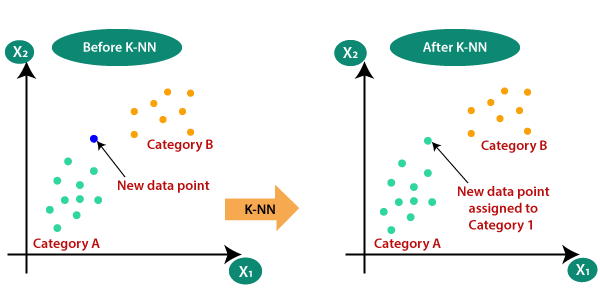

In [ ]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [ ]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [ ]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [ ]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [ ]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


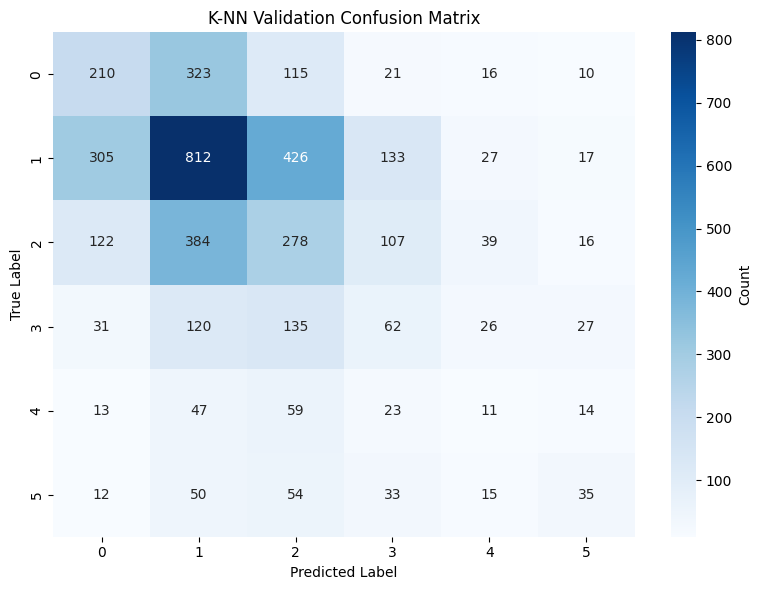

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [ ]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [ ]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [ ]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [ ]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Random number generator
rng = np.random.default_rng(seed=42)

# Load California Housing dataset
dataset = datasets.fetch_california_housing()

# Convert continuous target into integer classes
dataset.target = dataset.target.astype(int)


# Split function
def split(data, label, percent):
    rnd = rng.random(len(label))

    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]

    split2data = data[split2, :]
    split2label = label[split2]

    return split1data, split1label, split2data, split2label


# Create 80% training data and 20% test data
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data,
    dataset.target,
    0.20
)


# Nearest Neighbour classifier
def NN(traindata, trainlabel, valdata):
    model = KNeighborsClassifier(n_neighbors=1)
    model.fit(traindata, trainlabel)
    return model.predict(valdata)


# Random Classifier
def RandomClassifier(traindata, trainlabel, valdata):
    classes = np.unique(trainlabel)

    predictions = rng.choice(
        classes,
        size=len(valdata)
    )

    return predictions


# Accuracy function
def Accuracy(actual, predicted):
    return accuracy_score(actual, predicted)


# Validation percentages
validation_percentages = [
    0.10, 0.20, 0.25, 0.30,
    0.50, 0.75, 0.90, 0.999
]

nn_accuracies = []
random_accuracies = []


# Experiment
for percent in validation_percentages:

    traindata_exp, trainlabel_exp, valdata_exp, vallabel_exp = split(
        alltraindata,
        alltrainlabel,
        1 - percent
    )

    # Nearest Neighbour
    pred_nn = NN(
        traindata_exp,
        trainlabel_exp,
        valdata_exp
    )

    acc_nn = Accuracy(
        vallabel_exp,
        pred_nn
    )

    nn_accuracies.append(acc_nn)


    # Random Classifier
    pred_random = RandomClassifier(
        traindata_exp,
        trainlabel_exp,
        valdata_exp
    )

    acc_random = Accuracy(
        vallabel_exp,
        pred_random
    )

    random_accuracies.append(acc_random)


    print(
        f"Validation: {percent*100:.1f}% | "
        f"NN Accuracy: {acc_nn*100:.2f}% | "
        f"Random Accuracy: {acc_random*100:.2f}%"
    )

Validation: 10.0% | NN Accuracy: 33.58% | Random Accuracy: 17.62%
Validation: 20.0% | NN Accuracy: 34.64% | Random Accuracy: 16.94%
Validation: 25.0% | NN Accuracy: 34.28% | Random Accuracy: 16.56%
Validation: 30.0% | NN Accuracy: 34.98% | Random Accuracy: 16.34%
Validation: 50.0% | NN Accuracy: 33.31% | Random Accuracy: 16.89%
Validation: 75.0% | NN Accuracy: 32.06% | Random Accuracy: 17.28%
Validation: 90.0% | NN Accuracy: 29.16% | Random Accuracy: 16.23%
Validation: 99.9% | NN Accuracy: 22.12% | Random Accuracy: 16.58%


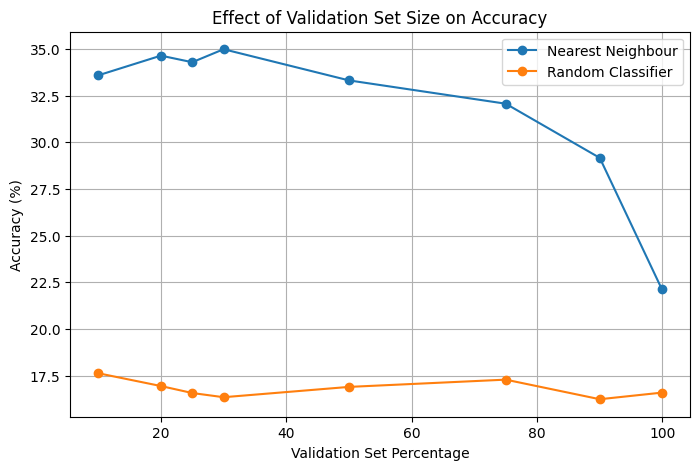

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    [p * 100 for p in validation_percentages],
    [a * 100 for a in nn_accuracies],
    marker='o',
    label='Nearest Neighbour'
)

plt.plot(
    [p * 100 for p in validation_percentages],
    [a * 100 for a in random_accuracies],
    marker='o',
    label='Random Classifier'
)

plt.xlabel("Validation Set Percentage")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Validation Set Size on Accuracy")
plt.legend()
plt.grid(True)
plt.show()



### 1. Effect of changing the validation set percentage

When we increase the percentage of the validation set, the validation set contains more samples. Therefore, the calculated validation accuracy generally becomes more stable because it is based on a larger number of samples. However, increasing the validation set also reduces the number of samples available for training the model.

When we reduce the percentage of the validation set, more data is available for training, which can help the model learn better. However, the validation set becomes smaller, so the measured validation accuracy can vary more from one random split to another.

For the nearest neighbour classifier, changing the split percentage can affect the validation accuracy because both the size of the training data and the size of the validation data change.

For the random classifier, the expected accuracy remains approximately \(1/\text{number of classes}\), which is about \(1/6\) in this experiment. However, the observed accuracy can fluctuate more when the validation set is very small.

### 2. Effect of train and validation set size on estimating test accuracy

The training set should be sufficiently large so that the classifier can learn useful patterns from the data. The validation set should also contain enough representative samples to provide a reliable estimate of how the model performs on unseen data.

If the validation set is too small, its accuracy can vary significantly depending on which samples are selected. If the training set is too small, the model may not learn sufficiently from the available data.

Therefore, there is a trade-off between having enough training data and having enough validation data. A moderate split provides a better balance for estimating the performance on the test set.

### 3. A suitable percentage for the validation set

A validation set of approximately **20% to 25%** of the available training data is a reasonable choice for this experiment. It provides enough samples to estimate validation accuracy while keeping most of the data available for training.

In the given notebook, using 75% for training and 25% for validation provides a good balance. The final test set is kept separate so that it can be used for the final evaluation.

### 4. Effect of extreme split values

With an extremely small validation percentage, such as 0.1%, the validation set contains very few samples. As a result, the accuracy can change considerably depending on the particular samples selected.

With an extremely large validation percentage, such as 99.9%, almost all the data is used for validation and very little data remains for training. This can make the nearest neighbour classifier perform poorly because it has very little training information.

Therefore, extreme split percentages are generally not suitable when we want a reliable model evaluation.


> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [ ]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [ ]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 33.58463539517022 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


1. Does averaging validation accuracy across multiple splits give more consistent results?

Yes. Averaging the validation accuracy across multiple random splits generally gives more consistent results than relying on a single train-validation split. A single split can produce an accuracy that depends strongly on which samples happen to be included in the validation set. Multiple splits reduce the effect of this random variation.

2. Does it give a more accurate estimate of test accuracy?

Averaging validation accuracy across multiple splits can provide a better estimate of the model's expected performance than using only one validation split. It reduces the dependence on one particular split and therefore gives a more reliable estimate.

However, it is not guaranteed that the average validation accuracy will exactly equal the test accuracy, because the validation and test sets contain different samples.

3. What is the effect of the number of iterations?

Increasing the number of iterations usually makes the average validation accuracy more stable because the result is calculated from a larger number of random splits.

With fewer iterations, the average can be affected more by the particular splits selected. With more iterations, the effect of individual splits is reduced. After a sufficiently large number of iterations, the improvement generally becomes smaller.

4. Can we handle a very small training or validation dataset by increasing iterations?

No. Increasing the number of iterations cannot completely solve the problem of having a very small training or validation dataset.

More iterations can reduce the variation caused by random splitting, but they cannot create new information. If the training set is too small, the model may not learn enough useful patterns. If the validation set is too small, its accuracy may still be an unreliable estimate for an individual split.

Therefore, an appropriate dataset split is important even when multiple iterations are used.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn import datasets

# Random number generator
rng = np.random.default_rng(seed=42)

# Load dataset
dataset = datasets.fetch_california_housing()
dataset.target = dataset.target.astype(int)

# Split function
def split(data, label, percent):
    rnd = rng.random(len(label))

    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]

    split2data = data[split2, :]
    split2label = label[split2]

    return split1data, split1label, split2data, split2label


# Keep 20% for testing and 80% for training
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data,
    dataset.target,
    0.20
)


# KNN function
def sklearn_knn_classifier(traindata, trainlabel, testdata, k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(traindata, trainlabel)
    return model.predict(testdata)


# Training percentages
split_sizes = [0.50, 0.60, 0.70, 0.75, 0.80, 0.90]

# Number of iterations
iterations_list = [1, 5, 10, 20]


# Experiment
for split_size in split_sizes:

    print("\nTraining percentage:", split_size * 100, "%")

    for iterations in iterations_list:

        accuracies_1nn = []
        accuracies_3nn = []

        for i in range(iterations):

            # Split training data into experiment-training and validation data
            train_exp, label_exp, val_exp, vallabel_exp = split(
                alltraindata,
                alltrainlabel,
                split_size
            )

            # 1-NN
            pred_1nn = sklearn_knn_classifier(
                train_exp,
                label_exp,
                val_exp,
                1
            )

            # 3-NN
            pred_3nn = sklearn_knn_classifier(
                train_exp,
                label_exp,
                val_exp,
                3
            )

            # Calculate accuracy
            accuracies_1nn.append(
                accuracy_score(vallabel_exp, pred_1nn)
            )

            accuracies_3nn.append(
                accuracy_score(vallabel_exp, pred_3nn)
            )

        # Average accuracy
        print(
            "Iterations:", iterations,
            "| 1-NN Average:",
            round(np.mean(accuracies_1nn) * 100, 2),
            "%",
            "| 3-NN Average:",
            round(np.mean(accuracies_3nn) * 100, 2),
            "%"
        )


Training percentage: 50.0 %
Iterations: 1 | 1-NN Average: 33.24 % | 3-NN Average: 33.79 %
Iterations: 5 | 1-NN Average: 33.14 % | 3-NN Average: 33.83 %
Iterations: 10 | 1-NN Average: 32.75 % | 3-NN Average: 33.38 %
Iterations: 20 | 1-NN Average: 33.14 % | 3-NN Average: 33.57 %

Training percentage: 60.0 %
Iterations: 1 | 1-NN Average: 33.58 % | 3-NN Average: 33.82 %
Iterations: 5 | 1-NN Average: 33.95 % | 3-NN Average: 33.86 %
Iterations: 10 | 1-NN Average: 33.58 % | 3-NN Average: 33.76 %
Iterations: 20 | 1-NN Average: 33.48 % | 3-NN Average: 34.14 %

Training percentage: 70.0 %
Iterations: 1 | 1-NN Average: 34.17 % | 3-NN Average: 35.34 %
Iterations: 5 | 1-NN Average: 33.95 % | 3-NN Average: 34.47 %
Iterations: 10 | 1-NN Average: 33.92 % | 3-NN Average: 34.38 %
Iterations: 20 | 1-NN Average: 34.01 % | 3-NN Average: 34.31 %

Training percentage: 75.0 %
Iterations: 1 | 1-NN Average: 35.01 % | 3-NN Average: 33.92 %
Iterations: 5 | 1-NN Average: 33.95 % | 3-NN Average: 34.53 %
Iterations

The K-Nearest Neighbors (KNN) classifier was evaluated using different training percentages and multiple iterations. Both 1-NN and 3-NN were tested using accuracy as the performance measure. The results show that accuracy generally remains in the range of approximately 33%–36%. Increasing the training percentage does not produce a perfectly increasing accuracy because the validation samples change randomly in each split. Repeated iterations provide more stable average accuracy values. Overall, 3-NN shows slightly better average performance than 1-NN in many of the experiments.